In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from collections import Counter

In [ ]:
class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        return np.array([self._predict(x) for x in X])

    def _predict(self, x):
        distances = [np.sqrt(np.sum((x - x_train)**2)) for x_train in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

In [ ]:
def get_data(dataset_func):
    data = dataset_func()
    X, y = data.data, data.target
    X = StandardScaler().fit_transform(X)
    return X, y

https://www.kaggle.com/datasets/uciml/iris

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html

In [ ]:
X_iris, y_iris = get_data(load_iris)

In [ ]:
# Как найти лучший k?

In [ ]:
# Кросс-валидация (Cross-Validation):
# Данные делят на части.
# Модель обучается на одних, а проверяется на других.
# Этот процесс повторяют для разных k:
# (например, от 1 до 50).

In [ ]:
# Метод «Локтя» (Elbow Method):
# Строят график зависимости ошибки от значения k.
# Обычно ошибка на валидации сначала быстро падает,
# а затем начинает расти (переобучение) или стабилизируется.
# Оптимальное k находится в «изгибе» этого графика.

In [ ]:
# Правило корня
# Берут квадратный корень из n (n - число сэмплов в выборке)

Кросс-валидация

In [ ]:
# Перемешиваем данные, так как в Iris классы идут подряд
indices = np.arange(X_iris.shape[0])
np.random.seed(42)
np.random.shuffle(indices)
X_iris, y_iris = X_iris[indices], y_iris[indices]

In [ ]:
k_neighbors = 5 # фиксируем k для соседей
n_folds = 5
fold_size = len(X_iris) // n_folds
accuracies = []

In [ ]:
for i in range(n_folds):
    start, end = i * fold_size, (i + 1) * fold_size

    X_val, y_val = X_iris[start:end], y_iris[start:end]
    X_train = np.concatenate([X_iris[:start], X_iris[end:]], axis=0)
    y_train = np.concatenate([y_iris[:start], y_iris[end:]], axis=0)

    knn = KNN(k=k_neighbors)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_val)

    acc = np.mean(preds == y_val)
    accuracies.append(acc)
    print(f"Фолд {i+1}: Точность = {acc:.4f}")

Фолд 1: Точность = 1.0000
Фолд 2: Точность = 0.9667
Фолд 3: Точность = 0.9667
Фолд 4: Точность = 0.9000
Фолд 5: Точность = 0.9667


In [ ]:
mean_acc = np.mean(accuracies)
print(f"\nСредняя точность по всем фолдам: {mean_acc:.4f}")


Средняя точность по всем фолдам: 0.9600


In [ ]:
# Как выбирается лучшая модель?
# Оценка стабильности:
# Мы смотрим на среднее значение точности и её разброс (стандартное отклонение).
# Если на одном фолде точность 0.95,
# а на другом 0.60 — модель нестабильна и переобучена.

# Выбор гиперпараметра: Если бы мы перебирали разные k
# (например, от 1 до 20), мы бы выбрали то k,
# которое дает самую высокую среднюю точность по итогам всех 5 фолдов.

# Финальный шаг: После того как с помощью кросс-валидации найдено оптимальное k,
# мы обучаем итоговую модель на всех доступных данных
# (100% датасета) с этим значением k.

Метод локтя

In [ ]:
data = load_iris()
X = StandardScaler().fit_transform(data.data)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Сбор данных об ошибке для разных k
k_values = range(1, 31)
errors = []

In [ ]:
for k in k_values:
    knn = KNN(k=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    error = np.mean(preds != y_test) # Доля неверных предсказаний
    errors.append(error)

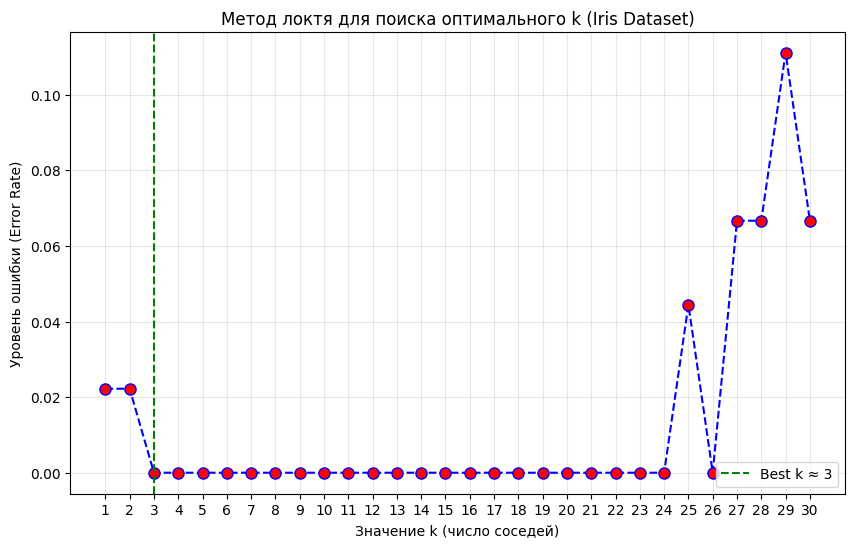

In [ ]:
# Визуализация метода локтя
plt.figure(figsize=(10, 6))
plt.plot(k_values, errors, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)

best_k = k_values[np.argmin(errors)]
plt.axvline(x=best_k, color='green', linestyle='--', label=f'Best k ≈ {best_k}')

plt.title('Метод локтя для поиска оптимального k (Iris Dataset)')
plt.xlabel('Значение k (число соседей)')
plt.ylabel('Уровень ошибки (Error Rate)')
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
print(f"Минимальная ошибка {min(errors):.4f} достигается при k = {best_k}")

Минимальная ошибка 0.0000 достигается при k = 3


Визулизация границ классов

In [ ]:
iris = load_iris()
X_subset = iris.data[:, :2]  # <--- Ключевое изменение: берем только 2 колонки
y = iris.target

scaler = StandardScaler()
X = scaler.fit_transform(X_subset)

k = 11
knn = KNN(k=k)
knn.fit(X, y) # Теперь X_train имеет форму (150, 2)

In [ ]:
# Создание сетки для отрисовки границ
h = .05  # шаг сетки
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Предсказание для каждой точки сетки
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

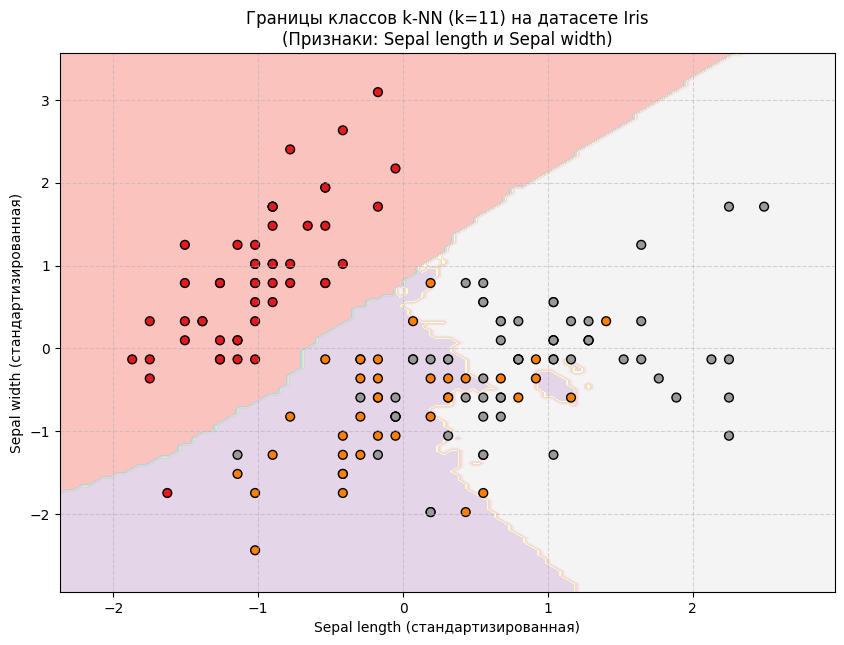

In [ ]:
# Визуализация
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, cmap=plt.cm.Pastel1, alpha=0.8) # Заливка областей
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Set1, edgecolor='k', s=40) # Точки данных

plt.title(f"Границы классов k-NN (k={k}) на датасете Iris\n(Признаки: Sepal length и Sepal width)")
plt.xlabel("Sepal length (стандартизированная)")
plt.ylabel("Sepal width (стандартизированная)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Лабораторная работа

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html

In [ ]:
# 1. Для датасета по вину обучить модель k-NN используя кросс-валидацию (k_folds=5)
# для подбора оптимального k от 1 до 15
# Оцениваете точность модели среднюю на каждой итерации, выбираете лучшее k по средней точности
# Выбрав лучшее k смотрите, какое разбиение взять
# Визуализировать границы классов

In [ ]:
X_wine, y_wine = get_data(load_wine)